In [13]:
import sys; sys.path.append("..")
from src.data import load_raw

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import REPORTS

ratings, movies, tags, links = load_raw()
eda_dir = REPORTS / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

ratings = ratings.copy()
movies = movies.copy()
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"] = ratings["datetime"].dt.year

print(f"Loaded {len(ratings):,} ratings, {len(movies):,} movies, "
      f"{len(tags):,} tags, and {len(links):,} links.")

Loaded 100,836 ratings, 9,742 movies, 3,683 tags, and 9,742 links.


## 1. Basic shape and data quality
How many ratings, users, and movies are present? Are there missing values or duplicate user-movie rating pairs?

In [14]:
tables = {"ratings": ratings, "movies": movies, "tags": tags, "links": links}
missing_by_table = pd.Series({name: int(frame.isna().sum().sum()) for name, frame in tables.items()})
duplicate_pairs = int(ratings.duplicated(["userId", "movieId"]).sum())
n_users = int(ratings["userId"].nunique())
n_movies = int(movies["movieId"].nunique())

print(f"Ratings: {len(ratings):,}; users: {n_users:,}; movies: {n_movies:,}.")
print("Missing values by table:")
print(missing_by_table.to_string())
print(f"Duplicate (userId, movieId) pairs: {duplicate_pairs:,}.")

Ratings: 100,836; users: 610; movies: 9,742.
Missing values by table:
ratings    0
movies     0
tags       0
links      8
Duplicate (userId, movieId) pairs: 0.


**Finding:** The dataset contains 100,836 ratings from 610 users across 9,742 movies. There are 8 missing values, all in `links`, and no duplicate user-movie rating pairs.

## 2. Rating distribution
How are the observed rating values distributed?

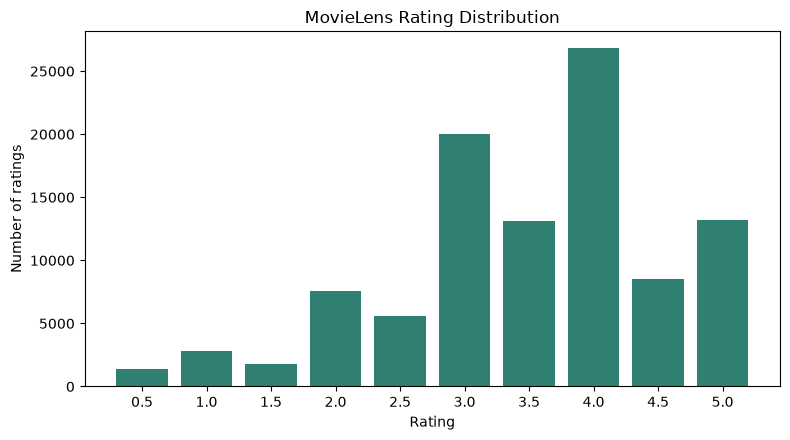

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211


In [15]:
rating_counts = ratings["rating"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#2f7f72")
ax.set(title="MovieLens Rating Distribution", xlabel="Rating", ylabel="Number of ratings")
fig.tight_layout()
fig.savefig(eda_dir / "02_rating_distribution.png", dpi=160)
plt.show()
print(rating_counts.to_string())

**Finding:** A 4.0 rating is most common (26,818 ratings), and 48.18% of all ratings are at least 4.0.

## 3. Matrix sparsity
What fraction of the user-movie rating matrix is unobserved?

In [16]:
sparsity = 1 - len(ratings) / (n_users * n_movies)
print(f"Matrix sparsity: {sparsity:.6%}")
print(f"Observed user-movie pairs: {len(ratings):,} of {n_users * n_movies:,}.")

Matrix sparsity: 98.303173%
Observed user-movie pairs: 100,836 of 5,942,620.


**Finding:** The matrix is 98.303173% sparse: only 100,836 of 5,942,620 possible user-movie combinations are rated.

## 4. Ratings per user
How many ratings does each user contribute, and what does the long tail look like?

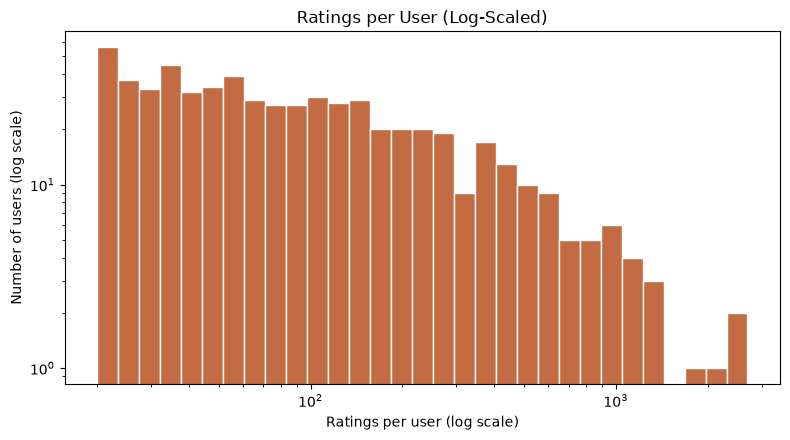

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
50%        70.500000
90%       400.300000
99%      1256.220000
max      2698.000000


In [17]:
user_rating_counts = ratings.groupby("userId").size()
fig, ax = plt.subplots(figsize=(8, 4.5))
user_bins = np.geomspace(user_rating_counts.min(), user_rating_counts.max(), 32)
ax.hist(user_rating_counts, bins=user_bins, color="#c36b42", edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(title="Ratings per User (Log-Scaled)", xlabel="Ratings per user (log scale)", ylabel="Number of users (log scale)")
fig.tight_layout()
fig.savefig(eda_dir / "04_ratings_per_user.png", dpi=160)
plt.show()
print(user_rating_counts.describe(percentiles=[0.5, 0.9, 0.99]).to_string())

**Finding:** Users contribute a median of 70.5 ratings (range 20–2,698), with a long tail: the 90th percentile is 400.3 ratings.

## 5. Ratings per movie and concentration
How quickly does movie popularity fall off, and what share of ratings belongs to the top 10% of movies?

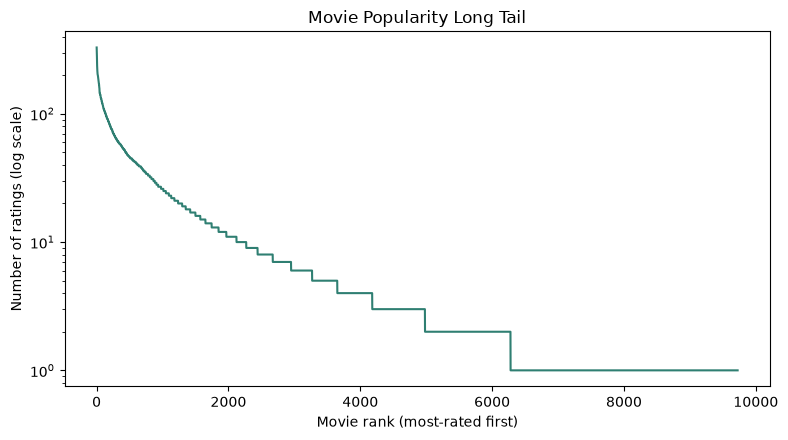

Top 10% of rated movies: 973 movies (60.05% of all ratings).
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
50%         3.000000
90%        27.000000
99%       114.540000
max       329.000000


In [18]:
movie_rating_counts = ratings.groupby("movieId").size().sort_values(ascending=False)
top_movie_count = int(np.ceil(0.10 * len(movie_rating_counts)))
top_decile_share = movie_rating_counts.iloc[:top_movie_count].sum() / movie_rating_counts.sum()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(movie_rating_counts) + 1), movie_rating_counts.values, color="#2f7f72", linewidth=1.5)
ax.set_yscale("log")
ax.set(title="Movie Popularity Long Tail", xlabel="Movie rank (most-rated first)", ylabel="Number of ratings (log scale)")
fig.tight_layout()
fig.savefig(eda_dir / "05_movie_rating_long_tail.png", dpi=160)
plt.show()
print(f"Top 10% of rated movies: {top_movie_count:,} movies ({top_decile_share:.2%} of all ratings).")
print(movie_rating_counts.describe(percentiles=[0.5, 0.9, 0.99]).to_string())

**Finding:** The top 10% comprises 973 movies and holds 60.05% of ratings; the most-rated movie has 329 ratings.

## 6. Popularity versus quality
Do movies with more ratings also receive higher mean ratings?

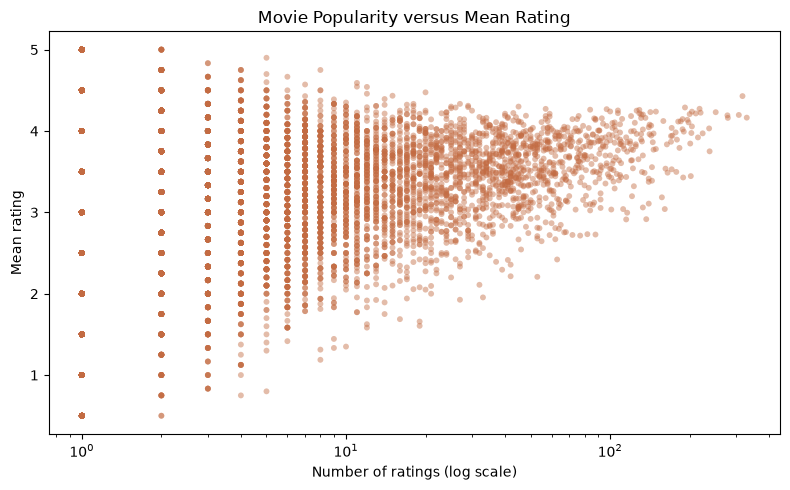

Correlation between log rating count and mean rating: 0.104.
Raw count-mean correlation: 0.127.


In [19]:
movie_summary = ratings.groupby("movieId")["rating"].agg(rating_count="size", mean_rating="mean")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(movie_summary["rating_count"], movie_summary["mean_rating"], alpha=0.45, s=18, color="#c36b42", edgecolors="none")
ax.set_xscale("log")
ax.set(title="Movie Popularity versus Mean Rating", xlabel="Number of ratings (log scale)", ylabel="Mean rating")
fig.tight_layout()
fig.savefig(eda_dir / "06_popularity_vs_quality.png", dpi=160)
plt.show()
popularity_quality_corr = movie_summary["rating_count"].corr(movie_summary["mean_rating"])
print(f"Correlation between log rating count and mean rating: {movie_summary['rating_count'].apply(np.log).corr(movie_summary['mean_rating']):.3f}.")
print(f"Raw count-mean correlation: {popularity_quality_corr:.3f}.")

**Finding:** Popularity has a weak positive association with mean rating: the log-count correlation is 0.104 (raw-count correlation 0.127).

## 7. Genre coverage and ratings
Which genres contain the most movies, and how do mean ratings compare by genre?

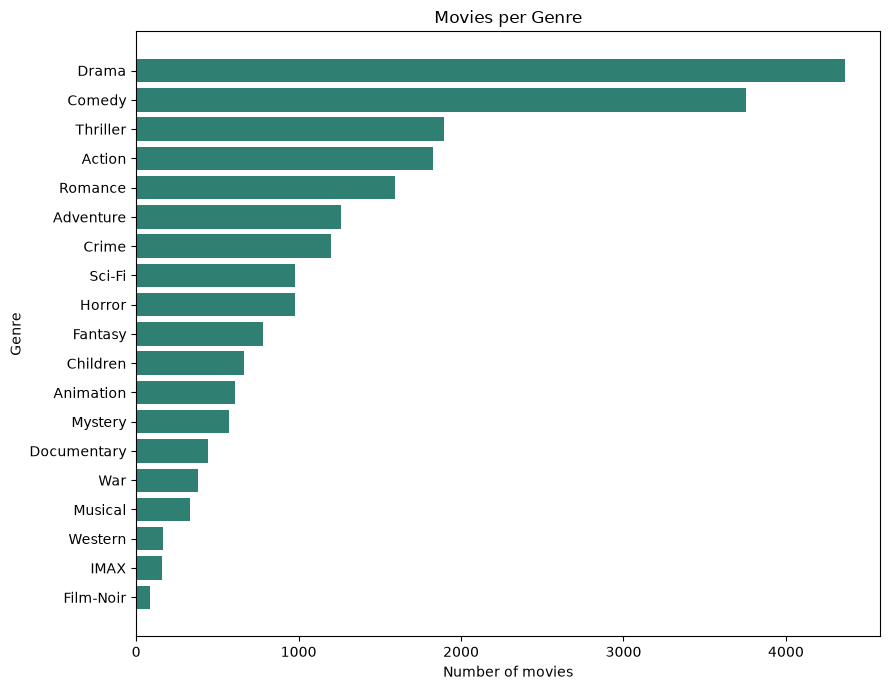

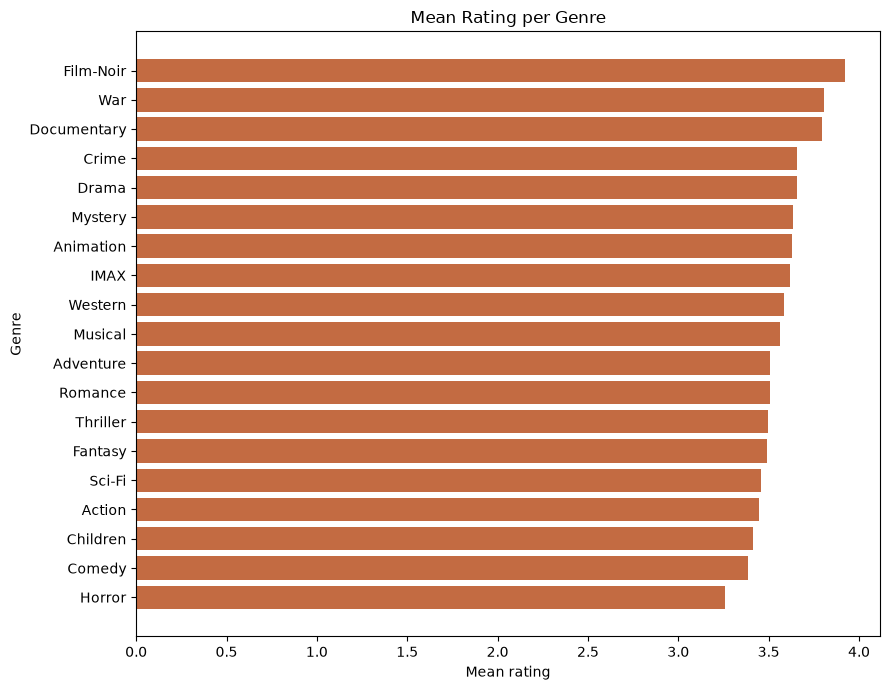

Most movies: Drama (4,361).
Highest mean rating: Film-Noir (3.920).
Lowest mean rating: Horror (3.258).


In [20]:
movie_genres = movies.assign(genre=movies["genres"].fillna("(no genres listed)").str.split("|")).explode("genre")
movie_genres = movie_genres.loc[movie_genres["genre"] != "(no genres listed)"]
genre_movie_counts = movie_genres.groupby("genre")["movieId"].nunique().sort_values()
genre_rating_rows = movie_genres[["movieId", "genre"]].merge(ratings[["movieId", "rating"]], on="movieId", how="inner")
genre_mean_ratings = genre_rating_rows.groupby("genre")["rating"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(genre_movie_counts.index, genre_movie_counts.values, color="#2f7f72")
ax.set(title="Movies per Genre", xlabel="Number of movies", ylabel="Genre")
fig.tight_layout()
fig.savefig(eda_dir / "07_movies_per_genre.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(genre_mean_ratings.index, genre_mean_ratings.values, color="#c36b42")
ax.set(title="Mean Rating per Genre", xlabel="Mean rating", ylabel="Genre")
fig.tight_layout()
fig.savefig(eda_dir / "07_mean_rating_per_genre.png", dpi=160)
plt.show()
print(f"Most movies: {genre_movie_counts.idxmax()} ({genre_movie_counts.max():,}).")
print(f"Highest mean rating: {genre_mean_ratings.idxmax()} ({genre_mean_ratings.max():.3f}).")
print(f"Lowest mean rating: {genre_mean_ratings.idxmin()} ({genre_mean_ratings.min():.3f}).")

**Finding:** Drama leads by movie count with 4,361 titles; Film-Noir has the highest mean rating (3.920), while Horror is lowest (3.258).

## 8. User rating behavior
How do users differ in their average rating levels?

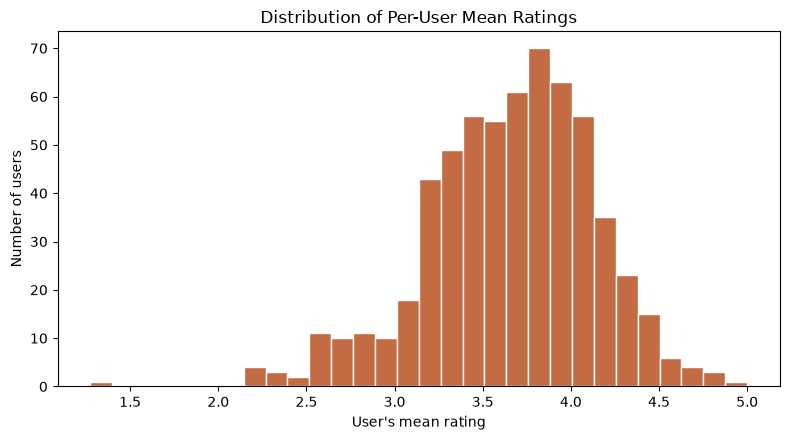

count    610.000000
mean       3.657222
std        0.480635
min        1.275000
10%        3.082493
50%        3.694385
90%        4.215079
max        5.000000


In [21]:
user_mean_ratings = ratings.groupby("userId")["rating"].mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(user_mean_ratings, bins=30, color="#c36b42", edgecolor="white")
ax.set(title="Distribution of Per-User Mean Ratings", xlabel="User's mean rating", ylabel="Number of users")
fig.tight_layout()
fig.savefig(eda_dir / "08_user_mean_ratings.png", dpi=160)
plt.show()
print(user_mean_ratings.describe(percentiles=[0.1, 0.5, 0.9]).to_string())

**Finding:** The mean of user-average ratings is 3.657 (median 3.694); the 10th–90th percentile range is 3.082–4.215.

## 9. Rating timeline and user activity span
When were ratings submitted, and how long does each user's observed activity last?

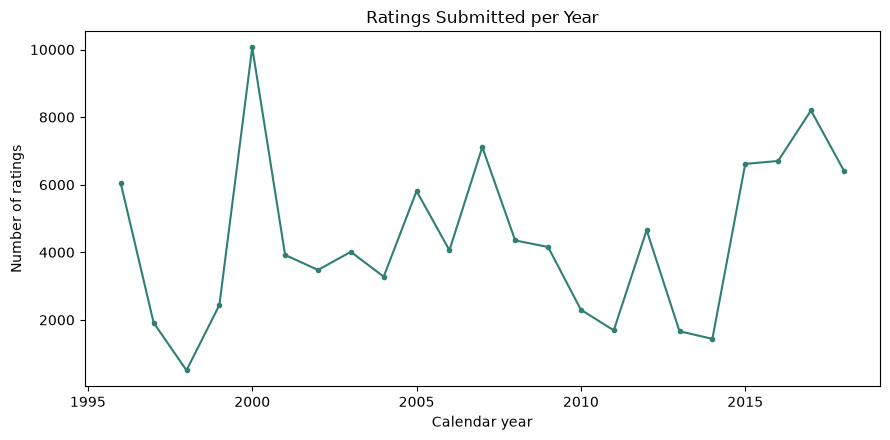

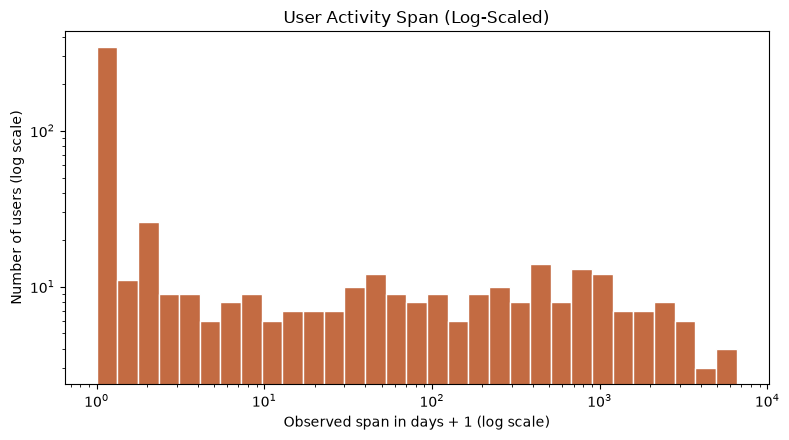

Rating years: 1996–2018.
count     610.000000
mean      234.295123
std       748.929398
min         0.000440
50%         0.054265
90%       616.567466
max      6557.197407


In [22]:
ratings_per_year = ratings.groupby("year").size()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ratings_per_year.index, ratings_per_year.values, marker="o", markersize=3, color="#2f7f72")
ax.set(title="Ratings Submitted per Year", xlabel="Calendar year", ylabel="Number of ratings")
fig.tight_layout()
fig.savefig(eda_dir / "09_ratings_by_year.png", dpi=160)
plt.show()

user_activity = ratings.groupby("userId")["datetime"].agg(first_seen="min", last_seen="max")
user_activity["span_days"] = (user_activity["last_seen"] - user_activity["first_seen"]).dt.total_seconds() / 86400
fig, ax = plt.subplots(figsize=(8, 4.5))
span_bins = np.geomspace(1, max(2, user_activity["span_days"].max() + 1), 32)
ax.hist(user_activity["span_days"] + 1, bins=span_bins, color="#c36b42", edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(title="User Activity Span (Log-Scaled)", xlabel="Observed span in days + 1 (log scale)", ylabel="Number of users (log scale)")
fig.tight_layout()
fig.savefig(eda_dir / "09_user_activity_span.png", dpi=160)
plt.show()
print(f"Rating years: {ratings_per_year.index.min()}–{ratings_per_year.index.max()}.")
print(user_activity["span_days"].describe(percentiles=[0.5, 0.9]).to_string())

**Finding:** Ratings span 1996-2018; median observed user activity lasts 0.054 days (about 1.3 hours), while the 90th percentile is 616.6 days.

## 10. Release-year effect
How do mean ratings vary by release year extracted from the movie title?

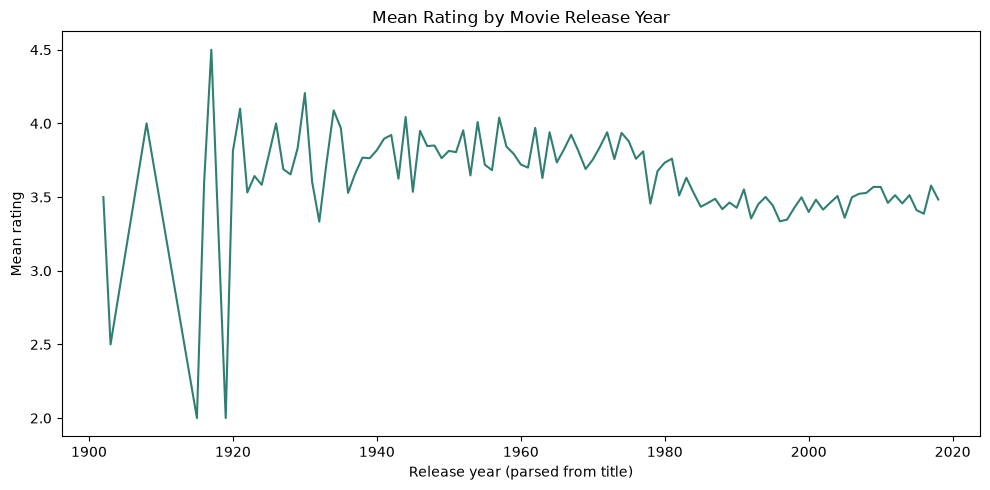

Parsed release years for 106 years; missing year on 13 movies.
Highest yearly mean: 1917 (4.500, 1 ratings).
Correlation of release year with yearly mean rating: -0.158.


In [23]:
movies["release_year"] = pd.to_numeric(
    movies["title"].str.extract(r"\((\d{4})\)\s*$", expand=False), errors="coerce"
)
ratings_with_release_year = ratings.merge(movies[["movieId", "release_year"]], on="movieId", how="left")
release_year_summary = ratings_with_release_year.dropna(subset=["release_year"]).groupby("release_year")["rating"].agg(mean_rating="mean", rating_count="size")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(release_year_summary.index, release_year_summary["mean_rating"], color="#2f7f72", linewidth=1.5)
ax.set(title="Mean Rating by Movie Release Year", xlabel="Release year (parsed from title)", ylabel="Mean rating")
fig.tight_layout()
fig.savefig(eda_dir / "10_mean_rating_by_release_year.png", dpi=160)
plt.show()
release_year_corr = release_year_summary.index.to_series().corr(release_year_summary["mean_rating"])
print(f"Parsed release years for {len(release_year_summary):,} years; missing year on {movies['release_year'].isna().sum():,} movies.")
print(f"Highest yearly mean: {release_year_summary['mean_rating'].idxmax():.0f} ({release_year_summary['mean_rating'].max():.3f}, {release_year_summary['rating_count'].loc[release_year_summary['mean_rating'].idxmax()]:,} ratings).")
print(f"Correlation of release year with yearly mean rating: {release_year_corr:.3f}.")

**Finding:** Titles yield release years for 106 years; the highest annual mean is 4.500 in 1917, based on only one rating. The correlation between release year and yearly mean rating is -0.158, a weak negative association.

## Key findings
- The dataset has 100,836 ratings from 610 users on 9,742 movies; `links.csv` contains 8 missing values, and there are no duplicate user-movie pairs.
- The full user-movie matrix is 98.303173% sparse, with 100,836 observed pairs out of 5,942,620 possible.
- A rating of 4.0 is most frequent (26,818 ratings); 48.18% of ratings are 4.0 or higher.
- The 973 most-rated movies (10% of rated movies) account for 60.05% of ratings; the most-rated title has 329 ratings.
- Drama is the largest genre by movie count (4,361); Film-Noir has the highest mean rating (3.920), and Horror the lowest (3.258).
- Users give an average rating of 3.657 on average (median user mean 3.694); the median user has rated 70.5 movies.
- Ratings span 1996-2018; median observed user activity is 0.054 days, compared with 616.6 days at the 90th percentile.
- Release-year mean ratings have a weak negative correlation (-0.158); the highest annual mean, 4.500 for 1917, is based on just one rating.